# Inspect Data

In [1]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback
import glob
import pandas as pd

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN 

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

### Generate analysis dataframe for hits with good triggers

In [2]:
# Configure your analysis here 
# This debug mode will process only the 10% of the dataset , use this if looking at source data
DEBUG = False

#input_dataset = "/global/cfs/cdirs/dune/www/data/2x2/reflows_run2/v0/flow/ColdOperations/data/2025_Operations_Cold/source/AmBe_1112"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin0/mod2_pmt_trig"
input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source"

MULTI = False

out_clusters = "../output/nosource_randtrig_ambe_bin2_one_trig_32us_window_eps1size4.csv"

In [3]:
def filter_hits(hits_set):
    # Remove hits with negative energy
    hits_set = hits_set[hits_set[:,3] > 0.]
    # Remove hits with any NaN field
    hits_set = hits_set[~np.isnan(hits_set).any(axis=1)]
    return hits_set 

In [4]:
def CL_AmBe_analysis(input_file,file_id,single=True,clust_eps=1,clust_min_samples=4):
    '''
    Produces AmBe analysis objects

    Column names:
    x, y, z, E, Q, light_id, cluster_label, file_id

    '''

    h5_file = h5flow.data.H5FlowDataManager(input_file,'r')
    g_triggers = None
    b_triggers = None

    # Initialize output dataset 
    out_dataset = {
        "clusters":None
    }

    if(single):
        g_triggers, b_triggers = classify_triggers_single(h5_file,debug=False)
    
    else: 
        first_trig = check_first_trig(h5_file,291)
        parity_str = None
        if(first_trig):
            parity_str = "odd"
        else:
            parity_str = "even"
        print(f"Parity of this file: {parity_str}")
        g_triggers, b_triggers = classify_triggers(h5_file,parity_str,debug=False)

    #print(f"List of good triggers: {g_triggers}")

    # Retrieve products linked to good triggers 
    light_events = h5_file['light/events',g_triggers]
    light_wvfms = h5_file['light/wvfm',g_triggers]
    charge_events = h5_file['light/events','charge/events',g_triggers]
    charge_hits = h5_file['light/events','charge/events','charge/calib_prompt_hits',g_triggers]

    # Charge
    non_zero_charge_hits = charge_hits[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_events = charge_events[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_light_ev = light_events[charge_events.data['nhit'][:,0] >= 1] 

    E_clusters = []
    n_cluster = [] 
    n_hits_clusters = [] 
    cluster_light_ev_id = [] 

    clusterized_hits = [] 

    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    for icharge in range(len(non_zero_charge_events)):
    #for icharge in range(2):
        test_event_hits = non_zero_charge_hits[:,0][icharge][0:non_zero_charge_events.data['nhit'][:,0][icharge]]
        this_event_light_id = non_zero_charge_light_ev['id'][icharge]
        hits_stack_unfiltered = np.column_stack((test_event_hits.data['x'],test_event_hits.data['y'],test_event_hits.data['z'],test_event_hits.data['E'],test_event_hits.data['Q'],np.ones(len(test_event_hits))*this_event_light_id))
        hits_stack = filter_hits(hits_stack_unfiltered)
        if(len(hits_stack)==0):
            continue
        labels = db.fit_predict(hits_stack[:,:3])
        hits_stack_label = np.column_stack((hits_stack[:,0],hits_stack[:,1],hits_stack[:,2],hits_stack[:,3],hits_stack[:,4],np.ones(len(hits_stack))*int(this_event_light_id),labels,np.ones(len(hits_stack))*int(file_id)))
        clusterized_hits.extend(hits_stack_label.tolist())
        temp_n_clusters = 0

        for l in np.unique(labels):
            if(l!=-1):
                this_l_hits = hits_stack_label[hits_stack_label[:,6]==l]
                n_hits_clusters.append(len(this_l_hits))
                E_clusters.append(np.sum(this_l_hits[:,3]))
                cluster_light_ev_id.append([l,this_event_light_id])
                temp_n_clusters+=1
            else:
                continue
        n_cluster.append(temp_n_clusters)

    out_dataset["clusters"] = clusterized_hits


    return out_dataset

In [5]:
def get_rand_trig(input_file,file_id,n_trigs,single=True,clust_eps=1,clust_min_samples=4):
    '''
    Produces AmBe analysis objects without light trigger selection

    Column names:
    x, y, z, E, Q, light_id, cluster_label, file_id
    '''

    h5_file = h5flow.data.H5FlowDataManager(input_file,'r')
    g_triggers = None
    b_triggers = None

    # Initialize output dataset
    out_dataset = {
        "clusters":None
    }

    # Randomly sample triggers
    if(single):
        g_triggers = np.random.choice(h5_file['light/events/data']['id'], size=n_trigs, replace=False)
    
    else: 
        first_trig = check_first_trig(h5_file,291)
        parity_str = None
        if(first_trig):
            parity_str = "odd"
        else:
            parity_str = "even"
        print(f"Parity of this file: {parity_str}")
        g_triggers = np.random.choice(h5_file['light/events/data']['id'], size=n_trigs, replace=False)

    #print(f"List of good triggers: {g_triggers}")

    # Retrieve products linked to good triggers 
    light_events = h5_file['light/events',g_triggers]
    light_wvfms = h5_file['light/wvfm',g_triggers]
    charge_events = h5_file['light/events','charge/events',g_triggers]
    charge_hits = h5_file['light/events','charge/events','charge/calib_prompt_hits',g_triggers]

    # Charge
    non_zero_charge_hits = charge_hits[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_events = charge_events[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_light_ev = light_events[charge_events.data['nhit'][:,0] >= 1] 

    E_clusters = []
    n_cluster = [] 
    n_hits_clusters = [] 
    cluster_light_ev_id = [] 

    clusterized_hits = [] 

    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    for icharge in range(len(non_zero_charge_events)):
    #for icharge in range(2):
        test_event_hits = non_zero_charge_hits[:,0][icharge][0:non_zero_charge_events.data['nhit'][:,0][icharge]]
        this_event_light_id = non_zero_charge_light_ev['id'][icharge]
        hits_stack_unfiltered = np.column_stack((test_event_hits.data['x'],test_event_hits.data['y'],test_event_hits.data['z'],test_event_hits.data['E'],test_event_hits.data['Q'],np.ones(len(test_event_hits))*this_event_light_id))
        hits_stack = filter_hits(hits_stack_unfiltered)
        if(len(hits_stack)==0):
            continue
        labels = db.fit_predict(hits_stack[:,:3])
        hits_stack_label = np.column_stack((hits_stack[:,0],hits_stack[:,1],hits_stack[:,2],hits_stack[:,3],hits_stack[:,4],np.ones(len(hits_stack))*int(this_event_light_id),labels,np.ones(len(hits_stack))*int(file_id)))
        clusterized_hits.extend(hits_stack_label.tolist())
        temp_n_clusters = 0

        for l in np.unique(labels):
            if(l!=-1):
                this_l_hits = hits_stack_label[hits_stack_label[:,6]==l]
                n_hits_clusters.append(len(this_l_hits))
                E_clusters.append(np.sum(this_l_hits[:,3]))
                cluster_light_ev_id.append([l,this_event_light_id])
                temp_n_clusters+=1
            else:
                continue
        n_cluster.append(temp_n_clusters)

    out_dataset["clusters"] = clusterized_hits


    return out_dataset

In [6]:
all_clusters = []

for file_count, ifile in enumerate(os.listdir(input_dataset)):

    # Run over 10% of the dataset
    if DEBUG and file_count >= int(len(os.listdir(input_dataset))*0.1):
        break

    this_file = os.path.join(input_dataset, ifile)
    print(this_file)

    try:
        '''
        temp_out = CL_AmBe_analysis(
            this_file,
            file_count,
            single=not MULTI
        )
        '''
        temp_out = get_rand_trig(
            this_file,
            file_count,
            100,
            single=not MULTI
        )
        all_clusters.extend(temp_out["clusters"])

    except Exception as e:
        print(f"[WARNING] Failed processing {this_file}: {e}")
        continue

all_clusters_array = np.array(all_clusters)

/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p11_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p44_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p67_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p6_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p8_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p39_v0p2.FLOW.hdf5
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_

KeyboardInterrupt: 

In [ ]:
# Inspect dimensions of different files

for ifile in np.unique(all_clusters_array[:,6]):
    print(f"Dimensions of file {ifile} {all_clusters_array[all_clusters_array[:,6]==ifile].shape}")

Dimensions of file -1.0 (4766, 8)
Dimensions of file 0.0 (405, 8)
Dimensions of file 1.0 (15, 8)


In [ ]:
df = pd.DataFrame(all_clusters_array, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id'])

df["id"] = (
    df["file_id"].astype(str)
    + "::" + df["light_id"].astype(str)
    + "::" + df["cluster_label"].astype(str)
)

df.to_csv(out_clusters)

In [ ]:
df.head()

,x,y,z,E,Q,light_id,cluster_label,file_id,id
0,-48.636985,-59.166187,20.890812,0.168370,5.002739,45.0,-1.0,0.0,0.0::45.0::-1.0
1,42.442749,-12.636900,10.221500,0.648863,19.279455,47.0,-1.0,0.0,0.0::47.0::-1.0
2,-51.845854,-61.854301,-63.872898,0.290966,8.645382,65.0,-1.0,0.0,0.0::65.0::-1.0
3,-13.509799,37.827564,48.049061,0.058802,1.747158,65.0,-1.0,0.0,0.0::65.0::-1.0
4,-61.536321,-56.976898,-45.250099,0.181174,5.383169,81.0,-1.0,0.0,0.0::81.0::-1.0


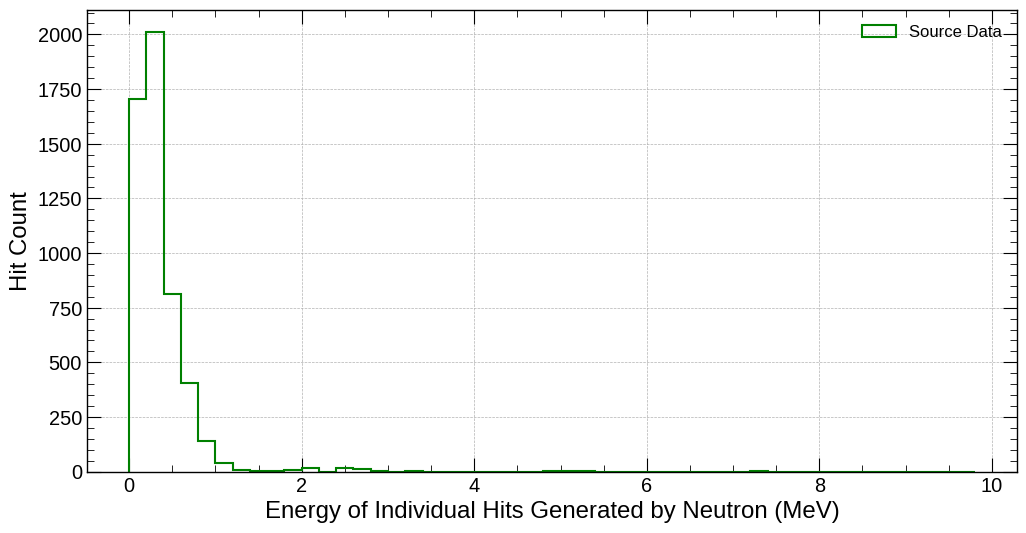

In [ ]:
# Visualize clustering results

# Energy histogram of individual hits

plt.figure(figsize=(12, 6))

plt.hist(df['E'], color='green', histtype='step', bins=np.arange(0,10,0.2), label='Source Data')

plt.xlabel('Energy of Individual Hits Generated by Neutron (MeV)')
plt.ylabel('Hit Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

### Compare datasets

In [6]:
# Load source data
df = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters_with_source.csv')

# Load source data clustered with more stringent parameters
df_eps1size4 = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data
df_nosource = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters.csv')

# Load no source data with more stringent parameters
df_nosource_eps1size4 = pd.read_csv('../output/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data with more stringent parameters and randomly chosen triggers
df_nosource_eps1size4_randtrig = pd.read_csv('../output/nosource_randtrig_ambe_bin2_one_trig_32us_window_eps1size4.csv')

In [ ]:
# Get cluster energies and cluster hit count
source_clusterE = []
source_clusterhitcount = []

source_eps1size4_clusterE = []
source_eps1size4_clusterhitcount = []

nosource_clusterE = []
nosource_clusterhitcount = []

nosource_eps1size4_clusterE = []
nosource_eps1size4_clusterhitcount = []

nosource_eps1size4_randtrig_clusterE = []
nosource_eps1size4_randtrig_clusterhitcount = []

# select n good triggers from the dataset

n = 10000

df_trig_ids = df['file_id'].astype(str)+ '::' + df['light_id'].astype(str)
for i in np.unique(df_trig_ids)[:n]:
    temp_ids = df['id'][(df_trig_ids==i) & (df['cluster_label']!=-1)]
    for j in np.unique(temp_ids):
        source_clusterE.append(sum(df['E'][df['id']==j]))
        source_clusterhitcount.append(len(df['E'][df['id']==j]))

print('1/5 Completed')

df_eps1size4_trig_ids = df_eps1size4['file_id'].astype(str)+ '::' + df_eps1size4['light_id'].astype(str)
for i in np.unique(df_eps1size4_trig_ids)[:n]:
    temp_ids = df_eps1size4['id'][(df_eps1size4_trig_ids==i) & (df_eps1size4['cluster_label']!=-1)]
    for j in np.unique(temp_ids):
        source_eps1size4_clusterE.append(sum(df_eps1size4['E'][df_eps1size4['id']==j]))
        source_eps1size4_clusterhitcount.append(len(df_eps1size4['E'][df_eps1size4['id']==j]))

print('2/5 Completed')

df_nosource_trig_ids = df_nosource['file_id'].astype(str)+ '::' + df_nosource['light_id'].astype(str)
for i in np.unique(df_nosource_trig_ids)[:n]:
    temp_ids = df_nosource['id'][(df_nosource_trig_ids==i) & (df_nosource['cluster_label']!=-1)]
    for j in np.unique(temp_ids):
        nosource_clusterE.append(sum(df_nosource['E'][df_nosource['id']==j]))
        nosource_clusterhitcount.append(len(df_nosource['E'][df_nosource['id']==j]))

print('3/5 Completed')

df_nosource_eps1size4_trig_ids = df_nosource_eps1size4['file_id'].astype(str)+ '::' + df_nosource_eps1size4['light_id'].astype(str)
for i in np.unique(df_nosource_eps1size4_trig_ids)[:n]:
    temp_ids = df_nosource_eps1size4['id'][(df_nosource_eps1size4_trig_ids==i) & (df_nosource_eps1size4['cluster_label']!=-1)]
    for j in np.unique(temp_ids):
        nosource_eps1size4_clusterE.append(sum(df_nosource_eps1size4['E'][df_nosource_eps1size4['id']==j]))
        nosource_eps1size4_clusterhitcount.append(len(df_nosource_eps1size4['E'][df_nosource_eps1size4['id']==j]))

print('4/5 Completed')

df_nosource_eps1size4_randtrig_trig_ids = df_nosource_eps1size4_randtrig['file_id'].astype(str)+ '::' + df_nosource_eps1size4_randtrig['light_id'].astype(str)
for i in np.unique(df_nosource_eps1size4_randtrig_trig_ids)[:n]:
    temp_ids = df_nosource_eps1size4_randtrig['id'][(df_nosource_eps1size4_randtrig_trig_ids==i) & (df_nosource_eps1size4_randtrig['cluster_label']!=-1)]
    for j in np.unique(temp_ids):
        nosource_eps1size4_randtrig_clusterE.append(sum(df_nosource_eps1size4_randtrig['E'][df_nosource_eps1size4_randtrig['id']==j]))
        nosource_eps1size4_randtrig_clusterhitcount.append(len(df_nosource_eps1size4_randtrig['E'][df_nosource_eps1size4_randtrig['id']==j]))

yo
yo
yo
yo


62
468


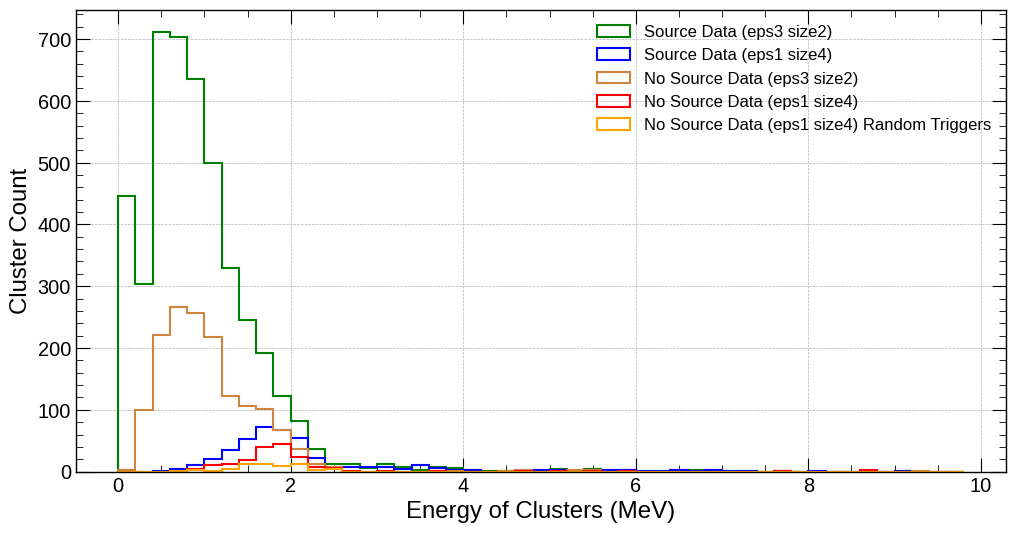

In [ ]:
# Visualize and compare

# Cluster energy

plt.figure(figsize=(12, 6))

plt.hist(source_clusterE, color='green', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps3 size2)')
plt.hist(source_eps1size4_clusterE, color='blue', histtype='step', bins=np.arange(0,10,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_clusterE, color='peru', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps3 size2)')
plt.hist(nosource_eps1size4_clusterE, color='red', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_randtrig_clusterE, color='orange', histtype='step', bins=np.arange(0,10,0.2), label='No Source Data (eps1 size4) Random Triggers')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

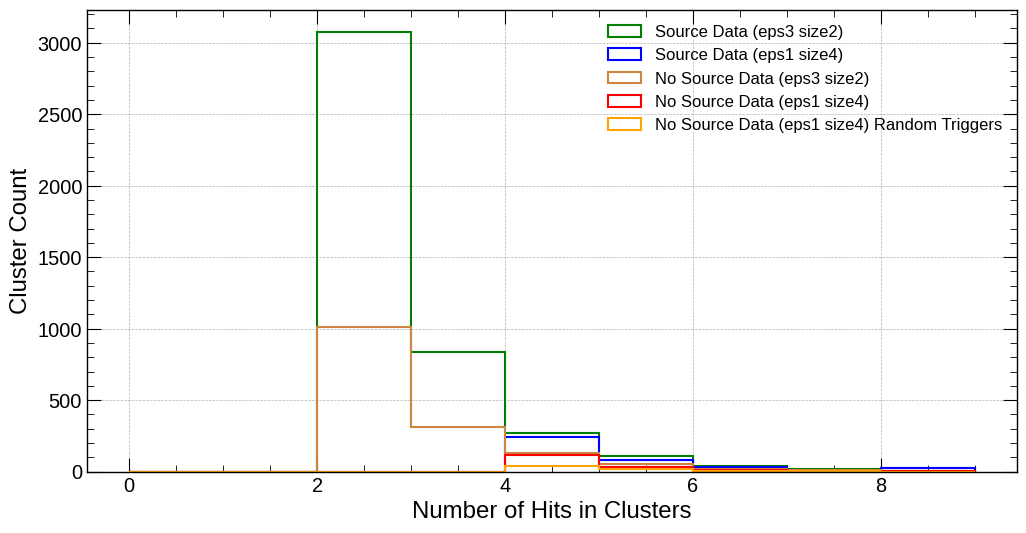

In [10]:
# Cluster hit count

plt.figure(figsize=(12, 6))

plt.hist(source_clusterhitcount, color='green', histtype='step', bins=np.arange(0,10,1), label='Source Data (eps3 size2)')
plt.hist(source_eps1size4_clusterhitcount, color='blue', histtype='step', bins=np.arange(0,10,1), label='Source Data (eps1 size4)')
plt.hist(nosource_clusterhitcount, color='peru', histtype='step', bins=np.arange(0,10,1), label='No Source Data (eps3 size2)')
plt.hist(nosource_eps1size4_clusterhitcount, color='red', histtype='step', bins=np.arange(0,10,1), label='No Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_randtrig_clusterhitcount, color='orange', histtype='step', bins=np.arange(0,10,1), label='No Source Data (eps1 size4) Random Triggers')

plt.xlabel('Number of Hits in Clusters')
plt.ylabel('Cluster Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [16]:
source_clusterE = np.array(source_clusterE)
source_clusterhitcount = np.array(source_clusterhitcount)

source_eps1size4_clusterE = np.array(source_eps1size4_clusterE)
source_eps1size4_clusterhitcount = np.array(source_eps1size4_clusterhitcount)

nosource_clusterE = np.array(nosource_clusterE)
nosource_clusterhitcount = np.array(nosource_clusterhitcount)

nosource_eps1size4_clusterE = np.array(nosource_eps1size4_clusterE)
nosource_eps1size4_clusterhitcount = np.array(nosource_eps1size4_clusterhitcount)

nosource_eps1size4_randtrig_clusterE = np.array(nosource_eps1size4_randtrig_clusterE)
nosource_eps1size4_randtrig_clusterhitcount = np.array(nosource_eps1size4_randtrig_clusterhitcount)

In [17]:
# Divide up the clusters with less than 5 hits and more than 5 hits

source_capturelike_E = source_clusterE[source_clusterhitcount>=5]
source_inelasticlike_E = source_clusterE[source_clusterhitcount<5]

source_eps1size4_capturelike_E = source_eps1size4_clusterE[source_eps1size4_clusterhitcount>=5]
source_eps1size4_inelasticlike_E = source_eps1size4_clusterE[source_eps1size4_clusterhitcount<5]

nosource_capturelike_E = nosource_clusterE[nosource_clusterhitcount>=5]
nosource_inelasticlike_E = nosource_clusterE[nosource_clusterhitcount<5]

nosource_eps1size4_capturelike_E = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount>=5]
nosource_eps1size4_inelasticlike_E = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount<5]

nosource_eps1size4_randtrig_capturelike_E = nosource_eps1size4_randtrig_clusterE[nosource_eps1size4_randtrig_clusterhitcount>=5]
nosource_eps1size4_randtrig_inelasticlike_E = nosource_eps1size4_randtrig_clusterE[nosource_eps1size4_randtrig_clusterhitcount<5]

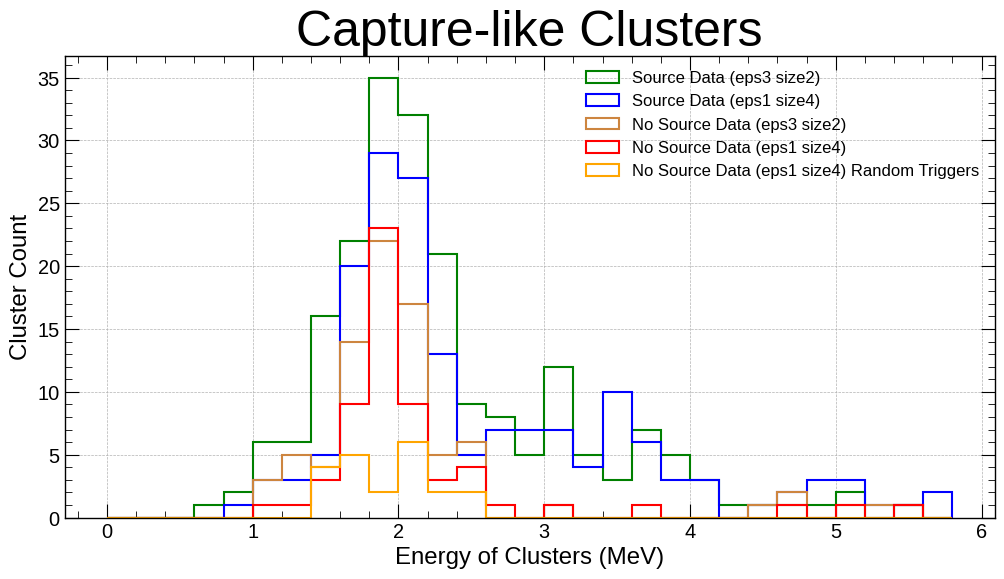

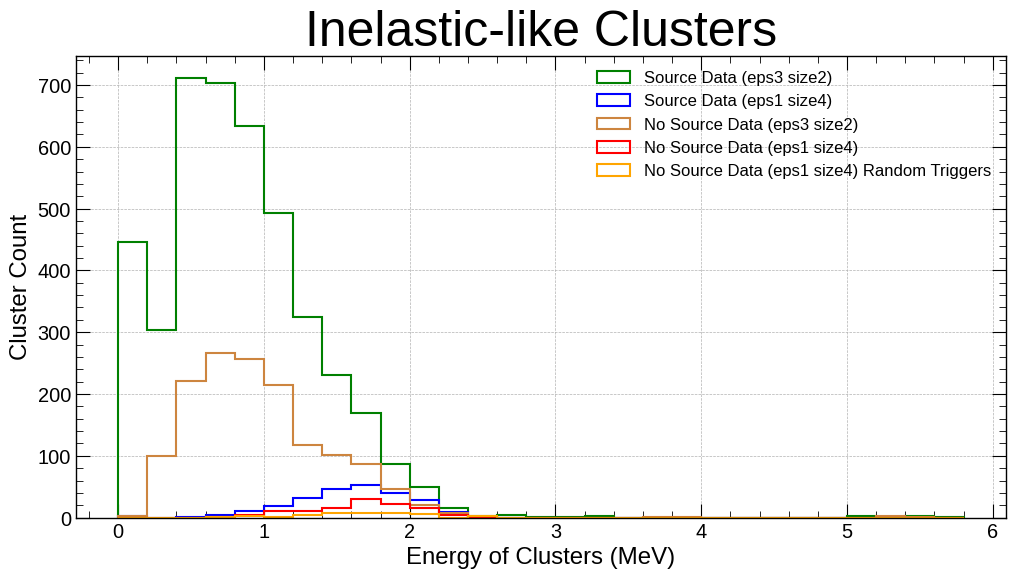

In [ ]:
# Cluster energy

plt.figure(figsize=(12, 6))

plt.hist(source_capturelike_E, color='green', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps3 size2)')
plt.hist(source_eps1size4_capturelike_E, color='blue', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_capturelike_E, color='peru', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps3 size2)')
plt.hist(nosource_eps1size4_capturelike_E, color='red', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_randtrig_capturelike_E, color='orange', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4) Random Triggers')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.title(r'Clusters with $\geq 5 hits$')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()


plt.figure(figsize=(12, 6))

plt.hist(source_inelasticlike_E, color='green', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps3 size2)')
plt.hist(source_eps1size4_inelasticlike_E, color='blue', histtype='step', bins=np.arange(0,6,0.2), label='Source Data (eps1 size4)')
plt.hist(nosource_inelasticlike_E, color='peru', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps3 size2)')
plt.hist(nosource_eps1size4_inelasticlike_E, color='red', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4)')
plt.hist(nosource_eps1size4_randtrig_inelasticlike_E, color='orange', histtype='step', bins=np.arange(0,6,0.2), label='No Source Data (eps1 size4) Random Triggers')

plt.xlabel('Energy of Clusters (MeV)')
plt.ylabel('Cluster Count')
plt.title('Clusters with < 5 hits')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [ ]:
# Function to calculate density of individual clusters

def get_hit_density(data_array):
    '''
    Calculate hit and charge density of clusters

    Hit/Charge density: The density of hits/charge in a spherical volume whose diameter is defined by the furthest two points in a cluster

    Output: Hit Density, Charge Density
    '''

    volume = []
    tot_charge = []
    hitnum = []

    for i in np.unique(data_array['id']):
        temp_arr = data_array[data_array['id']==i]
        temp_locs = np.column_stack((temp_arr['x'],temp_arr['y'],temp_arr['z']))
        for i in range(len(temp_arr)):
            diff = temp_locs[i+1:] - temp_locs[i]
            dist_sq = np.sum(diff**2, axis=1)
            
            if len(dist_sq) > 0:
                max_dist_sq = max(max_dist_sq, dist_sq.max())

        max_dist = np.sqrt(max_dist_sq)

        volume.append(4/3*np.pi*(max_dist/2)**3)
        tot_charge.append(sum(temp_arr['Q']))
        hitnum.append(len(temp_arr))

    volume = np.array(volume)
    tot_charge = np.array(tot_charge)
    hitnum = np.array(hitnum)

    return hitnum/volume, tot_charge/volume